# Ensemble Learning(앙상블 학습 방법)

*   앙상블(ensemble): ML에서 사용되는 일련의 모델(알고리즘)들.
    *   서로 다른 모델(알고리즘) 여러개를 훈련시키는 방법.
    *   한 가지 모델(알고리즘)을 서로 다른 훈련 셋으로 훈련시키는 방법.

*   앙상블 학습방법: 앙상블을 사용한 학습 방법
    *   투표(voting):  여러 개의 모델들을 같은 훈련 셋으로 학습시킨 후, 각각의 모델들의 예측값들을 투표(최빈값, 평균) 방식으로 결정하는 방법.
    *   **Bagging(Bootstrap Aggregating)**: **중복을 허용**해서 샘플링한 훈련 셋의 부분집합들로 여러개의 모델들을 학습시킨 후 예측(최빈값, 평균)하는 방법.
    *   Pasting: 중복을 허용하지 않고 샘플링한 훈련 셋의 부분집합들로 여러개의 모델들을 학습시킨 후 예측하는 방법.
    *   **Boosting**: 약한 학습기(weak learner)를 **순차적**으로 연결해서 강한 학습기(strong learner)를 만드는 앙상블 학습 방법.
        *   AdaBoost(Adaptive Boosting): 과소적합됐던 훈련 샘플들의 가중치를 높여서 그 다음 학습에서 사용하는 boosting 방법.
        *   Gradient Boosting: 잔여 오차(residual errors)들을 다음 훈련에서 학습시키는 boosting 방법.
*   **Random Forest**: Bagging을 이용한 Decision Tree들의 앙상블 학습 방법.

# Imports

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC  # SVM(Support Vector Machine) 알고리즘을 사용한 분류기
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# 데이터셋 준비

2개의 특성(x1, x2)과 2개의 클래스(0, 1)를 갖는 가상의 데이터셋 만들고 사용.

In [114]:
# x: 특성 배열, y: 타겟 배열
x, y = datasets.make_moons(n_samples=500, random_state=42, noise=0.3)

In [115]:
x.shape, y.shape

((500, 2), (500,))

In [116]:
np.unique(y, return_counts=True)

(array([0, 1]), array([250, 250]))

In [ ]:
x[:6]

array([[ 0.83067643, -0.40993581],
       [ 0.79835529,  0.83761218],
       [ 1.05046846, -0.48516193],
       [-0.25814276,  0.98000844],
       [ 0.3306816 ,  1.14763307],
       [ 1.26625226, -0.49698361]])

In [ ]:
y[:6]

array([1, 0, 1, 0, 0, 1])

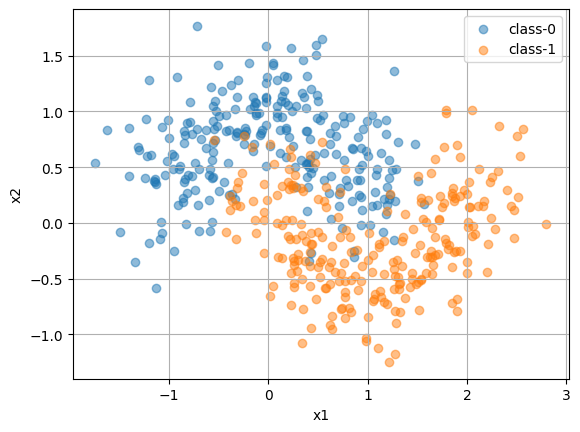

In [ ]:
plt.scatter(x=x[y == 0, 0], y=x[y == 0, 1], label='class-0', alpha=0.5)
plt.scatter(x=x[y == 1, 0], y=x[y == 1, 1], label='class-1', alpha=0.5)

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid()
plt.show()

# 머신 러닝 모델의 성능 비교

*   5개의 ML 모델 생성
    *   KNN, Decision Tree, Logistic Regression, SGD, SVM 기본 생성자
        *   SGDClassifier의 파라미터 중에서 loss='log_loss' 사용.
        *   SVC의 파라미터 중에서 probability=True 사용.
*   5개의 모델을 각각 훈련 셋으로 학습시킴
*   5개 모델의 점수(score -> 정확도)를 훈련/테스트 셋에서 계산, 출력.


In [109]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2, stratify=y)

In [ ]:
knn_clf = KNeighborsClassifier()
dt_clf = DecisionTreeClassifier()
lr_clf = LogisticRegression()
sgd_clf = SGDClassifier(loss='log_loss')
svm_clf = SVC(probability=True)

In [ ]:
clfs = [knn_clf, dt_clf, lr_clf, sgd_clf, svm_clf]
score_tr = []
score_te = []

for i in clfs:
    i.fit(X=x_train, y=y_train)
    tr_score = i.score(X=x_train, y=y_train)
    te_score = i.score(X=x_test, y=y_test)
    score_tr.append(tr_score)
    score_te.append(te_score)

print('classifier:', clfs)
print('Scores for train sets:', score_tr)
print('Scores for test sets:', score_te)

classifier: [KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression(), SGDClassifier(loss='log_loss'), SVC(probability=True)]
Scores for train sets: [1.0, 1.0, 0.875, 0.865, 1.0]
Scores for test sets: [1.0, 0.98, 0.84, 0.87, 1.0]


In [ ]:
# 강사님 답안
# 훈련 셋, 테스트 셋 나누기
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [ ]:
x_train.shape

(400, 2)

In [ ]:
# 성능을 비교하기 위한 예측기(estimator)
knn = KNeighborsClassifier(n_jobs=-1)
tree = DecisionTreeClassifier(random_state=42)
logistic = LogisticRegression(random_state=42, n_jobs=-1)
sgd = SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)
svc = SVC(probability=True, random_state=42)

In [ ]:
estimators = [knn, tree, logistic, sgd, svc]
for clf in estimators:
    clf.fit(X=x_train, y=y_train)  # 모델 훈련
    train_score = clf.score(X=x_train, y=y_train)  # 훈련 셋 점수(정확도)
    test_score = clf.score(X=x_test, y=y_test)  # 테스트 셋 점수(정확도)
    print(f'{clf.__class__.__name__}: train score={train_score}, test_score={test_score}')

KNeighborsClassifier: train score=0.93, test_score=0.93
DecisionTreeClassifier: train score=1.0, test_score=0.84
LogisticRegression: train score=0.8475, test_score=0.81
SGDClassifier: train score=0.8425, test_score=0.81
SVC: train score=0.9275, test_score=0.93


# Voting Ensemble

In [ ]:
# VotingClassifier 객체 생성
voting_clf = VotingClassifier(estimators=[('knn', knn),
                                          ('tree', tree),
                                          ('logistic', logistic),
                                          ('sgd', sgd),
                                          ('svc', svc)],
                              voting='soft',
                              n_jobs=-1)

VotingClassifier 생성자 파라미터:
*   estimators: 앙상블을 만들기 위한 예측기(ML 모델)들의 리스트.
    *   (str, estimator) 형식의 튜플들을 리스트의 아이템으로 설정.
*   voting: 투표 방식
    *   voting='hard': 기본값. 단순한 다수결로 예측. 각각의 예측기에서 예측 확률을 계산할 필요가 없음.
    *   voting='soft': 각각의 예측기에서 계산한 예측 확률을 가중치로 곱한 값을 사용해서 최종 결과를 도출.
    *   일반적으로 soft voting 방식이 성능이 더 좋다고 알려져 있음.

In [ ]:
# VotingClassifier 훈련
voting_clf.fit(X=x_train, y=y_train)

VotingClassifier(estimators=[('knn', KNeighborsClassifier(n_jobs=-1)),
                             ('tree', DecisionTreeClassifier(random_state=42)),
                             ('logistic',
                              LogisticRegression(n_jobs=-1, random_state=42)),
                             ('sgd',
                              SGDClassifier(loss='log_loss', n_jobs=-1,
                                            random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [ ]:
print('train score =', voting_clf.score(X=x_train, y=y_train))
print('test score=', voting_clf.score(X=x_test, y=y_test))

train score = 0.94
test score= 0.92


# Bagging Ensemble

In [ ]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1,
    random_state=42)

BaggingClassifier 생성자 파라미터:
*   estimator: 앙상블을 만들기 위한 예측기.
*   n_estimators: 예측기 개수. 기본값 10.
*   max_samples: 훈련 셋에서 랜덤 샘플링한 부분 집합이 가질 수 있는 최대 샘플 개수(정수) 또는 비율(0.0 ~ 1.0). 기본값 1.0
*   bootstrap: 중복 허용 샘플링 여부.
    *   bootstrap=True: 중복 허용. bagging(bootstrap aggregating). 기본값.
    *   bootstrap=False: 중복 허용 않음. pasting.
*   oob_score: OOB(Out-of-Bagging) 샘플들을 사용해서 검증 점수를 계산할 지 여부. 기본값은 False.
    *   OOB samples: 중복 허용 샘플링을 하는 동안 한 번도 샘플링되지 못하고 남아있는 훈련 셋 샘플. 한 번도 훈련되지 못한 훈련 샘플들.
    *   OOB 샘플들은 검증 셋 역할을 할 수 있음.

In [ ]:
# BaggingClassifier 훈련
bagging_clf.fit(X=x_train, y=y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, oob_score=True, random_state=42)

In [ ]:
bagging_clf.oob_score_  # OOB 샘플들을 사용한 검증 점수

0.89

In [ ]:
bagging_clf.score(X=x_train, y=y_train)  # 훈련 셋 점수(정확도)

1.0

In [ ]:
bagging_clf.score(X=x_test, y=y_test)  # 테스트 셋 점수(정확도)

0.89

*   estimator: Decision Tree
*   n_estimators: 100
*   교차검증(cross_validate)

In [ ]:
bag = BaggingClassifier(DecisionTreeClassifier(random_state=42), 100, n_jobs=-1, random_state=42)
cv_moon = cross_validate(bag, x_train, y_train, n_jobs=-1, return_train_score=True)
cv_moon

{'fit_time': array([0.65859151, 0.55982256, 0.49226046, 0.56694484, 0.46833444]),
 'score_time': array([0.06391191, 0.07167912, 0.07819033, 0.07971859, 0.03714371]),
 'test_score': array([0.875 , 0.925 , 0.9375, 0.925 , 0.875 ]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [ ]:
np.mean(cv_moon['test_score'])

np.float64(0.9075)

*   estimator: Decision Tree
*   n_estimators: 50
*   max_samples: 100
*   교차검증(cross_validate)

In [ ]:
bag = BaggingClassifier(DecisionTreeClassifier(random_state=42), 50, n_jobs=-1, max_samples=100, random_state=42)
cv_moon = cross_validate(bag, x_train, y_train, n_jobs=-1, return_train_score=True)
cv_moon

{'fit_time': array([0.35831094, 0.34782934, 0.33576846, 0.24252701, 0.19474864]),
 'score_time': array([0.0400362 , 0.03504181, 0.0327456 , 0.04949594, 0.02593398]),
 'test_score': array([0.875 , 0.95  , 0.9125, 0.9   , 0.925 ]),
 'train_score': array([0.95    , 0.93125 , 0.946875, 0.940625, 0.940625])}

In [ ]:
np.mean(cv_moon['test_score'])

np.float64(0.9125)

In [ ]:
# 강사님 답안
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

In [ ]:
cv = cross_validate(estimator=bagging_clf, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [ ]:
cv

{'fit_time': array([0.89733696, 1.1085012 , 0.75983405, 0.65893745, 0.57156801]),
 'score_time': array([0.0739615 , 0.12877035, 0.06116819, 0.08120131, 0.03844762]),
 'test_score': array([0.875 , 0.925 , 0.9375, 0.925 , 0.875 ]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [ ]:
print('train_score=', np.mean(cv['train_score']))
print('test_score=', np.mean(cv['test_score']))

train_score= 1.0
test_score= 0.9075


In [ ]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=100,
    n_jobs=-1,
    random_state=42)

In [ ]:
cv = cross_validate(estimator=bagging_clf, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [ ]:
print('train score=', np.mean(cv['train_score']))
print('test score=', np.mean(cv['test_score']))

train score= 0.9418749999999999
test score= 0.9125


# Random Forest

Random Forest: bagging(bootstrap aggregating)을 사용한 결정 나무(decision tree)들의 앙상블 학습 방법.
*   DecisionTreeClassifier의 파라미터들을 가지고 있음.
*   BaggingClassifier의 파라미터들을 가지고 있음.
*   CV으로 decision tree와 bagging의 하이퍼 파라미터들을 튜닝할 수 있음.

In [60]:
forest = RandomForestClassifier(n_estimators=50, max_samples=100,
                                random_state=42, n_jobs=-1)

In [63]:
cv = cross_validate(estimator=forest, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [64]:
print('train score=', np.mean(cv['train_score']))
print('test score=', np.mean(cv['test_score']))

train score= 0.9493750000000001
test score= 0.9274999999999999


GridSearchCV 사용한 Random Forest 하이퍼 파라미터 튜닝

In [71]:
forest = RandomForestClassifier(random_state=42, n_jobs=-1)
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': np.arange(2, 11),
    'min_samples_split': np.arange(2, 11, 2),
    'max_samples': [0.25, 0.5, 0.75, 1.0]
}

grid = GridSearchCV(
        estimator=forest,
        param_grid=params,
        n_jobs=-1,
        return_train_score=True
)

In [72]:
grid.fit(X=x_train, y=y_train)

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_samples': [0.25, 0.5, 0.75, 1.0],
                         'min_samples_split': array([ 2,  4,  6,  8, 10]),
                         'n_estimators': [50, 100, 200]},
             return_train_score=True)

In [74]:
grid.best_score_

np.float64(0.925)

In [75]:
grid.best_params_

{'max_depth': np.int64(6),
 'max_samples': 1.0,
 'min_samples_split': np.int64(2),
 'n_estimators': 200}

# Random Forest를 사용한 wine 분류

## 데이터셋 준비

In [121]:
wine_df = pd.read_csv('https://bit.ly/wine_csv_data')

In [122]:
wine_df.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [123]:
feature_names = wine_df.columns[:3]
x = wine_df[feature_names].values  # 특성 배열
y = wine_df['class'].values  # 타겟 배열

In [124]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

## Random Forest 교차 검증

In [125]:
forest_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
cv = cross_validate(
        estimator = forest_clf,
        X = x_train,
        y = y_train,
        n_jobs=-1,
        return_train_score=True
    )

In [126]:
cv

{'fit_time': array([1.51981997, 1.40134978, 0.94568276, 1.15903282, 0.70777822]),
 'score_time': array([0.16177416, 0.13391542, 0.0800252 , 0.07688212, 0.04862022]),
 'test_score': array([0.90480769, 0.89903846, 0.88546679, 0.89412897, 0.88546679]),
 'train_score': array([0.99807554, 0.99807554, 0.9983165 , 0.998076  , 0.9983165 ])}

In [127]:
print('train score =', np.mean(cv['train_score']))
print('test score=', np.mean(cv['test_score']))

train score = 0.9981720130385032
test score= 0.8937817428000298


## Random Forest 하이퍼 파라미터 튜닝

In [128]:
params = {
    'n_estimators': [10, 50, 100, 150],
    'max_depth': np.arange(2, 11),
    'min_samples_split': [2, 10, 20, 50],
    'min_impurity_decrease': [0.0, 0.001, 0.01, 0.1]
}

In [129]:
grid_cv = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=1), param_grid=params, n_jobs=-1)

In [130]:
grid_cv.fit(X=x_train, y=y_train)

GridSearchCV(estimator=RandomForestClassifier(n_jobs=1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'min_impurity_decrease': [0.0, 0.001, 0.01, 0.1],
                         'min_samples_split': [2, 10, 20, 50],
                         'n_estimators': [10, 50, 100, 150]})

In [131]:
grid_cv.best_score_

np.float64(0.8820457910712964)

In [132]:
grid_cv.best_params_

{'max_depth': np.int64(10),
 'min_impurity_decrease': 0.0,
 'min_samples_split': 2,
 'n_estimators': 100}

In [133]:
# Grid Search CV가 찾은 최적의 모델로 훈련 셋 점수 계산
best_model = grid_cv.best_estimator_
best_model.score(X=x_train, y=y_train)  #> 과대적합이 줄어듬.

0.9297671733692515

# Extra Tree

Extra Tree
*   Random Forest와 비슷한 점:
    *   여러 개(기본값 100)의 decision tree들을 훈련시키는 앙상블 학습.
    *   decision tree의 파라미터(max_depth, min_samples_split, ...)들을 튜닝할 수 있음.
*   Random Forest와 다른 점:
    *   bagging을 사용하지 않음.
        *   여러 개의 decision tree들을 전체 훈련 셋을 사용해서 훈련시킴.
    *   노드를 분할할 때 가장 좋은 분할 방법을 찾는 게 아니라 무작위(random)로 분할.
        *   Random Forest 각각의 tree들이 최적의 노드 분할을 찾기 위해서 많은 훈련 시간이 필요.
        *   Extra Tree는 무작위 분할을 하기 때문에 훈련 시간이 빠름.

In [134]:
extra_tree = ExtraTreesClassifier(n_jobs=-1, random_state=42)

In [135]:
cv = cross_validate(estimator=extra_tree, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [136]:
cv

{'fit_time': array([0.6628077 , 0.64951158, 0.93254471, 1.00659633, 0.65131545]),
 'score_time': array([0.10064125, 0.08738565, 0.12634659, 0.14055324, 0.05952692]),
 'test_score': array([0.89519231, 0.90480769, 0.88450433, 0.89509143, 0.8825794 ]),
 'train_score': array([0.99807554, 0.99807554, 0.9983165 , 0.998076  , 0.9983165 ])}

In [137]:
print('train_score =', np.mean(cv['train_score']))
print('test_score =', np.mean(cv['test_score']))

train_score = 0.9981720130385032
test_score = 0.8924350336862368


# Gradient Boosting
*   깊이(depth)가 얕은 결정 나무들을 순차적으로(직렬로) 연결해서 훈련시킴.
*   훈련 과정에서, 이전 훈련 단계에서 발생한 오차들을 그 다음 훈련에서 가중치를 주고 훈련시킴.
    *   오차들을 학습하는 알고리즘.
*   장점: 깊이가 얕은 결정 나무들을 사용하기 때문에, 과대적합이 작아지고 높은 일반화 성능을 기대할 수 있음.
*   단점: Random Forest처럼 병렬로 훈련시킬 수가 없기 때문에 훈련 시간이 느림.
*   SGD + Decision Tree + Ensemble 하이퍼 파라미터들을 튜닝할 수 있음.

In [138]:
grad_boost = GradientBoostingClassifier(random_state=42)

In [139]:
cv = cross_validate(estimator=grad_boost, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [140]:
cv

{'fit_time': array([0.91926742, 1.14429069, 0.90107584, 0.77239466, 0.4709177 ]),
 'score_time': array([0.00804543, 0.01365137, 0.004915  , 0.00507617, 0.00381637]),
 'test_score': array([0.87692308, 0.87692308, 0.86717998, 0.87680462, 0.85948027]),
 'train_score': array([0.88501323, 0.88645658, 0.89009139, 0.88287638, 0.88624339])}

In [141]:
print('train score =', np.mean(cv['train_score']))
print('test score =', np.mean(cv['test_score']))
#> 과대적합이 거의 없음.

train score = 0.886136193834053
test score = 0.8714622047827053


# Histogram 기반 Gradient Boosting

노드를 분할할 때 최적의 노드를 빠르게 찾을 수 있음.

In [143]:
hist_gb = HistGradientBoostingClassifier(random_state=42)

In [144]:
cv = cross_validate(estimator=hist_gb, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [145]:
print('train score =', np.mean(cv['train_score']))
print('test score =', np.mean(cv['test_score']))

train score = 0.930536541746549
test score = 0.8780021470348707


# XGBoost(Extreme Gradient Boosting)

In [149]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

In [150]:
# 1. 모델 객체 생성
xgb_clf = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# 2. 모델 학습
xgb_clf.fit(x_train, y_train)

# 3. 예측 수행
y_pred = xgb_clf.predict(x_test)

# 4. 결과 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"모델 정확도: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

모델 정확도: 0.8623
              precision    recall  f1-score   support

         0.0       0.73      0.70      0.72       320
         1.0       0.90      0.91      0.91       980

    accuracy                           0.86      1300
   macro avg       0.82      0.81      0.81      1300
weighted avg       0.86      0.86      0.86      1300



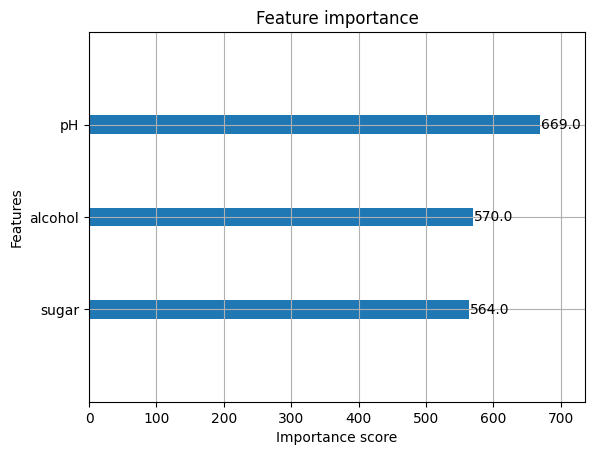

In [156]:
feature_names = ['alcohol', 'sugar', 'pH']
xgb_clf.get_booster().feature_names = feature_names
xgb.plot_importance(xgb_clf)
plt.show()

# Light GBM

In [158]:
from lightgbm import LGBMClassifier

In [161]:
lgbm_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=5,
    min_split_gain=0,
    is_unbalance=True,
    random_state=42
)

# 2. 모델 학습
lgbm_clf.fit(x_train, y_train)

# 3. 예측 수행
y_pred = lgbm_clf.predict(x_test)

# 4. 결과 평가
print(f"정확도: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 3918, number of negative: 1279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 384
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.753896 -> initscore=1.119503
[LightGBM] [Info] Start training from score 1.119503
정확도: 0.8515
              precision    recall  f1-score   support

         0.0       0.65      0.87      0.74       320
         1.0       0.95      0.85      0.90       980

    accuracy                           0.85      1300
   macro avg       0.80      0.86      0.82      1300
weighted avg       0.88      0.85      0.86      1300



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
